<a href="https://colab.research.google.com/github/khushichoudhary842-source/Online-Store-Orders/blob/main/Massive_Employee_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Data cleaning Manually**

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


        City  Total_Salary
0  Bangalore      41098078
1      Delhi      23396695
3      delhi      20340084
2     Mumbai      16896133
4     mumbai      16854872


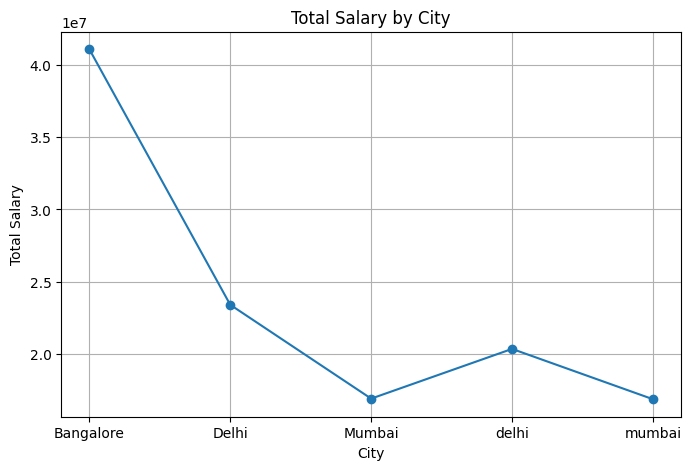

In [74]:
import pandas as pd
df = pd.read_excel('/content/drive/MyDrive/Messy_Employee_Dataset_1280Rows.xlsx')
df
import matplotlib.pyplot as plt
city_salary = df.groupby('City').agg(Total_Salary=('Salary','sum')).reset_index()
print(city_salary.sort_values(by='Total_Salary', ascending=False))
plt.figure(figsize=(8,5))
plt.plot(city_salary['City'],
         city_salary['Total_Salary'],
         marker='o')
plt.title('Total Salary by City')
plt.xlabel('City')
plt.ylabel('Total Salary')
plt.grid(True)
plt.show()

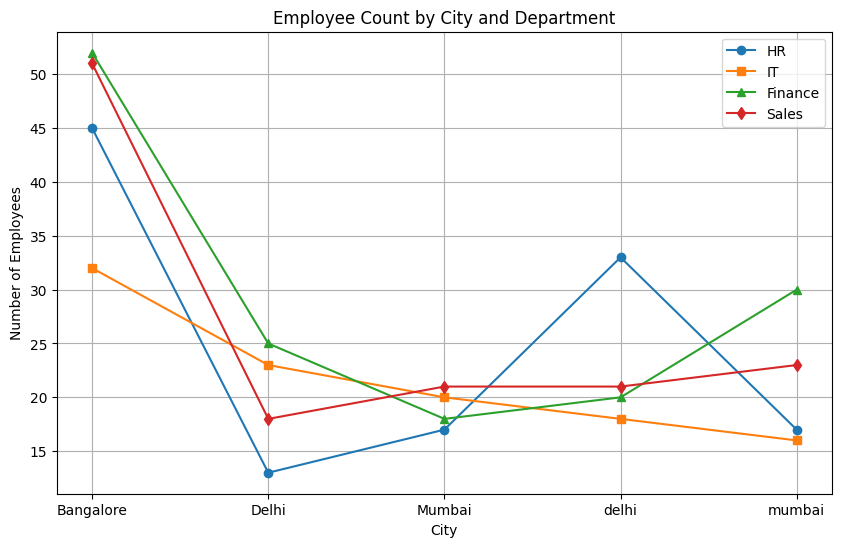

In [79]:
city_dept = df.groupby(['City', 'Department']).size().unstack(fill_value=0)
plt.figure(figsize=(10,6))
plt.plot(city_dept.index, city_dept['HR'],
         marker='o', label='HR')
plt.plot(city_dept.index, city_dept['IT'],
         marker='s', label='IT')
plt.plot(city_dept.index, city_dept['Finance'],
         marker='^', label='Finance')
plt.plot(city_dept.index, city_dept['Sales'],
         marker='d', label='Sales')
plt.title('Employee Count by City and Department')
plt.xlabel('City')
plt.ylabel('Number of Employees')
plt.legend()
plt.grid(True)

plt.show()

**Employee ID Vs Salary**

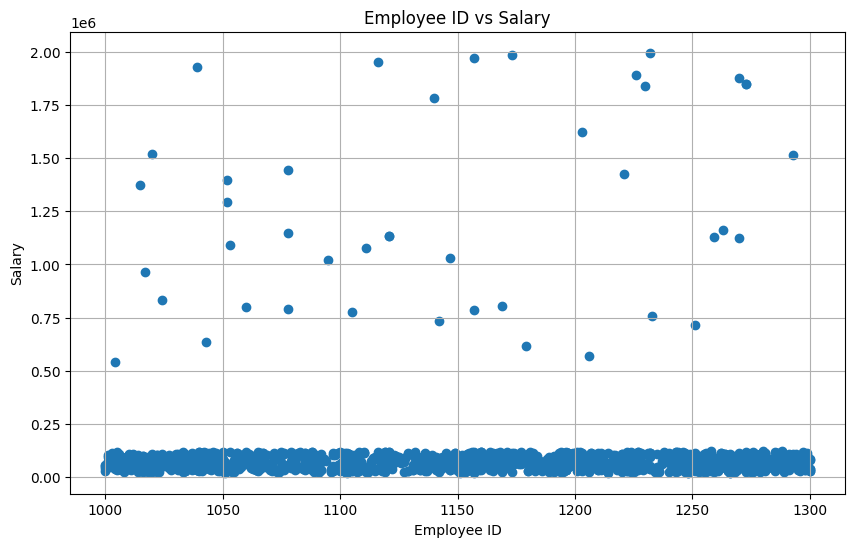

In [85]:
plt.figure(figsize=(10,6))
plt.scatter(df['EmployeeID'], df['Salary'])
plt.title('Employee ID vs Salary')
plt.xlabel('Employee ID')
plt.ylabel('Salary')
plt.grid(True)
plt.show()

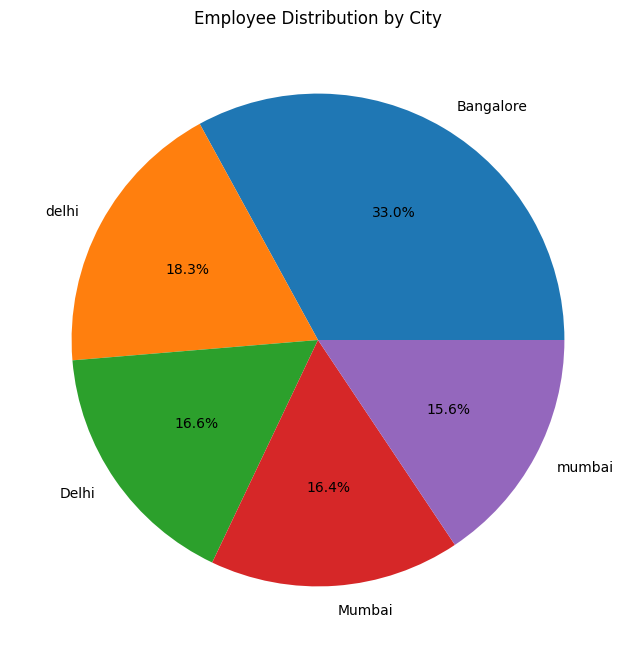

In [90]:
city_count = df['City'].value_counts()
plt.figure(figsize=(8,8))
plt.pie(city_count, labels=city_count.index,
        autopct='%1.1f%%')
plt.title('Employee Distribution by City')
plt.show()

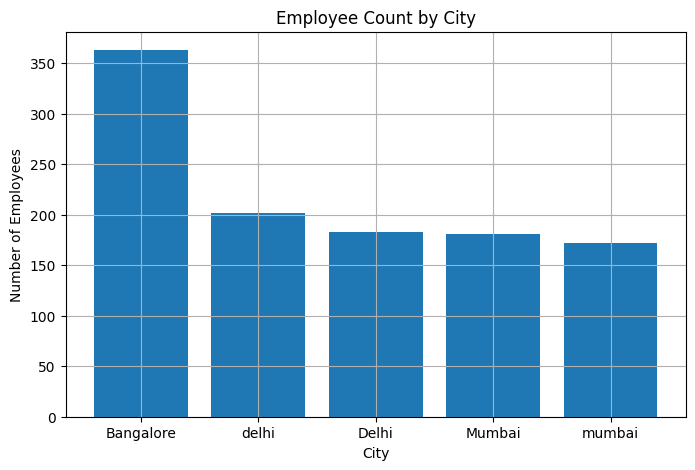

In [92]:
city_count = df['City'].value_counts()
plt.figure(figsize=(8,5))
plt.bar(city_count.index, city_count.values)
plt.title('Employee Count by City')
plt.xlabel('City')
plt.ylabel('Number of Employees')
plt.grid(True)
plt.show()

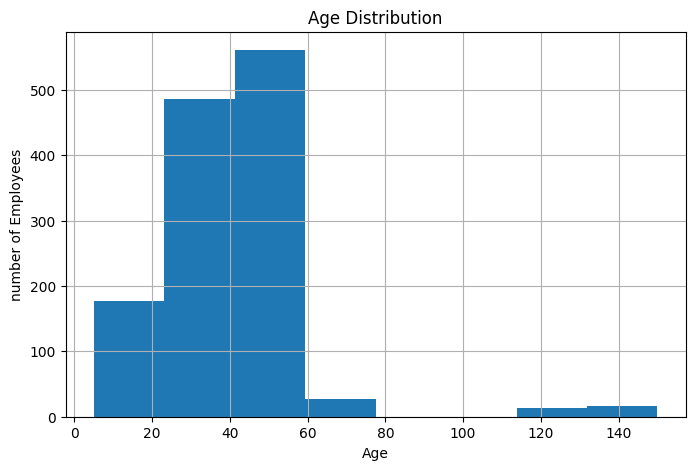

In [99]:
plt.figure(figsize=(8,5))
plt.hist(df['Age'], bins=8)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('number of Employees')
plt.grid(True)
plt.show()

In [4]:
df.shape

(1280, 8)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1280 entries, 0 to 1279
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   EmployeeID  1280 non-null   int64 
 1   Name        1280 non-null   object
 2   Age         1280 non-null   int64 
 3   Salary      1280 non-null   int64 
 4   Department  1153 non-null   object
 5   Email       1219 non-null   object
 6   JoinDate    1280 non-null   object
 7   City        1101 non-null   object
dtypes: int64(3), object(5)
memory usage: 80.1+ KB


In [6]:
df.describe()

,EmployeeID,Age,Salary
count,1280.000000,1280.000000,1.280000e+03
mean,1151.059375,41.496875,1.097576e+05
std,86.656672,19.370831,2.313165e+05
min,1000.000000,5.000000,2.000400e+04
25%,1075.000000,28.000000,4.512175e+04
50%,1153.000000,41.000000,7.116450e+04
75%,1226.000000,51.000000,9.855225e+04
max,1300.000000,150.000000,1.995897e+06


**Finding Missing Values:**

In [7]:
df.isnull().sum()

,0
EmployeeID,0
Name,0
Age,0
Salary,0
Department,127
Email,61
JoinDate,0
City,179


**Handle Missing Values:**

In [8]:
df['Department'].unique()

array([nan, 'IT', 'hr', 'Finance', 'HR', 'Sales', 'FINANCE',
       'Human Resources', 'it'], dtype=object)

In [9]:
df['Department'] = df['Department'].fillna('Unknown')

**Email**

In [10]:
df['Email'].isnull().sum()

np.int64(61)

**Replace**

In [11]:
df['Email'] = df['Email'].fillna('Not Available')

**Replace missing city:**

In [12]:
df['City'] = df['City'].fillna('Unknown')

**Finding Duplicate Rows**

**Check Duplicates:**

In [13]:
df.duplicated().sum()

np.int64(80)

**Display Duplicates:**

In [14]:
df[df.duplicated()]

,EmployeeID,Name,Age,Salary,Department,Email,JoinDate,City
1200,1085,Danielle Carroll,34,113242,hr,michaelowens@example.com,2019-07-10 00:00:00,mumbai
1201,1278,Amy Stevenson,18,56942,FINANCE,mollyhoward@example.net,2020-11-06 00:00:00,Unknown
1202,1037,Melissa Webb,40,59210,FINANCE,eavila@example.com,2019-11-28 00:00:00,Mumbai
1203,1156,Jeremiah Dickerson,24,99511,it,stephen75@example.com,2016-10-22 00:00:00,Bangalore
1204,1129,Mr. James Garcia,150,26826,Finance,ophillips@example.com,2026-04-16 00:00:00,Bangalore
...,...,...,...,...,...,...,...,...
1275,1037,Jennifer Thompson,50,109899,hr,meghan19@example.com,2020-06-07 00:00:00,mumbai
1276,1279,Angela Young,37,109783,Sales,brandonortiz@example.com,2024-10-18 00:00:00,mumbai
1277,1273,ANTHONY RIVERA,43,1847943,FINANCE,pflores@example.org,2025-08-21 00:00:00,Delhi
1278,1250,John Richardson,56,105563,hr,chunt@example.net,2022-05-19 00:00:00,Bangalore


**Remove duplicates:**

In [15]:
df = df.drop_duplicates()

**Verify:**

In [16]:
df.duplicated().sum()

np.int64(0)

**Clean Text Formatting:**

In [17]:
df['City'].unique()

array(['Delhi', 'Mumbai', 'Bangalore', 'mumbai', 'delhi', 'Unknown'],
      dtype=object)

In [18]:
df['City'] = df['City'].str.strip()
df['City'] = df['City'].str.title()

/tmp/ipykernel_1123/503049039.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['City'] = df['City'].str.strip()
/tmp/ipykernel_1123/503049039.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['City'] = df['City'].str.title()


In [19]:
df['City'].unique()

array(['Delhi', 'Mumbai', 'Bangalore', 'Unknown'], dtype=object)

**Standardize Department Names**

In [20]:
df['Department'].unique()

array(['Unknown', 'IT', 'hr', 'Finance', 'HR', 'Sales', 'FINANCE',
       'Human Resources', 'it'], dtype=object)

In [21]:
df['Department'] = df['Department'].replace({'hr':'HR','it':'IT','FINANCE':'Finance'})

/tmp/ipykernel_1123/1850767797.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Department'] = df['Department'].replace({'hr':'HR','it':'IT','FINANCE':'Finance'})


In [22]:
df['Department'].unique()

array(['Unknown', 'IT', 'HR', 'Finance', 'Sales', 'Human Resources'],
      dtype=object)

**Clean Employee Names**

In [23]:
df['Name'].head(20)

,Name
0,AMY GONZALEZ
1,Jasmine Davis
2,James Ross
3,Kristen Shaw
4,Laura Cunningham
5,Scott Armstrong
6,Lucas James
7,Lydia Mcdaniel
8,Traci Anderson
9,Jay Singh


In [24]:
df['Name'] = df['Name'].str.strip()
df['Name'] = df['Name'].str.title()

/tmp/ipykernel_1123/2244507228.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Name'] = df['Name'].str.strip()
/tmp/ipykernel_1123/2244507228.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Name'] = df['Name'].str.title()


**Detect Age Outliers**

In [25]:
df['Age'].describe()

,Age
count,1200.000000
mean,41.515833
std,19.367257
min,5.000000
25%,28.000000
50%,41.000000
75%,51.000000
max,150.000000


In [26]:
df[df['Age']> 100]

,EmployeeID,Name,Age,Salary,Department,Email,JoinDate,City
58,1129,Mr. James Garcia,150,26826,Finance,ophillips@example.com,2026-04-16 00:00:00,Bangalore
63,1035,Renee Terry Dds,120,84251,Finance,rochabrandi@example.com,2026-03-21 00:00:00,Bangalore
72,1116,Jordan Wright,150,36591,HR,allennoah@example.org,2023-11-23 00:00:00,Delhi
250,1203,Amy Owens,120,79054,Finance,amandaholden@example.org,2024-05-01 00:00:00,Delhi
260,1279,Jessica Baker Phd,150,80505,IT,uarmstrong@example.net,2025-03-22 00:00:00,Bangalore
334,1112,Jenna Rivera,150,46406,Finance,melissa29@example.com,2026-02-09 00:00:00,Unknown
394,1194,Kristine Jones,150,115325,Human Resources,smithmatthew@example.net,2023-03-13 00:00:00,Mumbai
400,1060,Michael Juarez Phd,120,74046,Unknown,Not Available,2017-02-15 00:00:00,Bangalore
406,1258,Douglas Young,150,26366,Finance,atucker@example.org,2020-06-24 00:00:00,Bangalore
416,1160,James West,120,46619,Sales,neil34@example.net,2021-08-16 00:00:00,Bangalore


In [27]:
df = df[(df['Age'] >= 18) & (df['Age'] <= 60)]

In [28]:
df['Age'].describe()

,Age
count,1165.000000
mean,39.561373
std,12.578512
min,18.000000
25%,28.000000
50%,40.000000
75%,51.000000
max,60.000000


**Detect Salary Outliers**

In [29]:
df['Salary'].describe()

,Salary
count,1.165000e+03
mean,1.096423e+05
std,2.312240e+05
min,2.000400e+04
25%,4.510600e+04
50%,7.150500e+04
75%,9.850400e+04
max,1.995897e+06


In [30]:
df[df['Salary'] > 200000]

,EmployeeID,Name,Age,Salary,Department,Email,JoinDate,City
18,1173,James Marshall,53,1984450,HR,andrew16@example.org,2018-01-29 00:00:00,Unknown
56,1273,Anthony Rivera,43,1847943,Finance,pflores@example.org,2025-08-21 00:00:00,Delhi
94,1169,Belinda Ferguson,46,802315,Finance,rachel95@example.org,2024-11-26 00:00:00,Delhi
108,1203,James Davenport,53,1625273,HR,amyhendrix@example.net,2020-01-04 00:00:00,Bangalore
223,1270,Benjamin Gilbert,32,1125712,Sales,walkerlinda@example.net,2025-11-26 00:00:00,Bangalore
252,1078,Darren Oconnor,38,1146483,Sales,williamsrhonda@example.net,2025-08-22 00:00:00,Delhi
289,1024,Christina Rocha,58,831315,Sales,brennanernest@example.com,2026-03-17 00:00:00,Mumbai
324,1043,Darin Cooley,34,635207,IT,moniquewhite@example.com,2021-02-06 00:00:00,Delhi
338,1157,Michael Reed,36,1972218,Finance,lorimaldonado@example.org,2022-02-06 00:00:00,Bangalore
358,1121,Peter Patterson,48,1135552,IT,garciajesse@example.com,2019-11-11 00:00:00,Bangalore


In [31]:
df = df[df['Salary'] <= 200000]

**Fixing Invalid Dates**

In [32]:
df['JoinDate'] = pd.to_datetime(df['JoinDate'],errors='coerce')

In [33]:
df['JoinDate'].isnull().sum()

np.int64(29)

In [34]:
df = df.dropna(subset=['JoinDate'])

**Checking Employee ID Duplicates**

In [35]:
df['EmployeeID'].duplicated().sum()

np.int64(801)

In [36]:
df[df['EmployeeID'].duplicated()]

,EmployeeID,Name,Age,Salary,Department,Email,JoinDate,City
12,1136,Devin Coleman,39,76985,HR,wrightandrew@example.org,2024-11-18,Mumbai
34,1057,Stephanie George,27,68393,Human Resources,stephaniecoleman@example.net,2018-09-18,Mumbai
41,1197,Vanessa Mcdonald,30,112901,Unknown,bethany36@example.com,2019-03-01,Bangalore
44,1291,Beverly Franklin,53,59829,Finance,ltaylor@example.com,2016-10-28,Mumbai
53,1169,Tony Henson,44,75069,HR,welchjonathan@example.org,2018-04-28,Mumbai
...,...,...,...,...,...,...,...,...
1195,1106,Jason Collins,20,54481,IT,amanda57@example.net,2019-01-15,Bangalore
1196,1092,Larry Brady,32,107552,Finance,dakotaosborne@example.org,2021-08-18,Mumbai
1197,1049,James Campbell,36,78611,Finance,nguyenlindsey@example.org,2024-03-16,Mumbai
1198,1058,Lynn Moore,43,83404,Sales,robertorobinson@example.com,2017-12-09,Delhi


In [37]:
df = df.drop_duplicates(subset='EmployeeID',keep='first')

**FINAL CHECK**

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 296 entries, 0 to 1161
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   EmployeeID  296 non-null    int64         
 1   Name        296 non-null    object        
 2   Age         296 non-null    int64         
 3   Salary      296 non-null    int64         
 4   Department  296 non-null    object        
 5   Email       296 non-null    object        
 6   JoinDate    296 non-null    datetime64[ns]
 7   City        296 non-null    object        
dtypes: datetime64[ns](1), int64(3), object(4)
memory usage: 20.8+ KB


In [39]:
df.isnull().sum()

,0
EmployeeID,0
Name,0
Age,0
Salary,0
Department,0
Email,0
JoinDate,0
City,0


In [40]:
df.duplicated().sum()

np.int64(0)

**Save Cleaned Dataset**

In [41]:
df.to_csv('Cleaned_Employee_Dataset.csv',index=False)

In [42]:
from google.colab import files
files.download('Cleaned_Employee_Dataset.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Data Cleaning Automatically**

In [43]:
import pandas as pd
import numpy as np


In [44]:
df = pd.read_excel('/content/drive/MyDrive/Messy_Employee_Dataset_1280Rows.xlsx')
print("Original Shape:", df.shape)

Original Shape: (1280, 8)


In [45]:
df['Department'] = df['Department'].fillna('Unknown')
df['Email'] = df['Email'].fillna('Not Available')
df['City'] = df['City'].fillna('Unknownn')
print("Departments after Cleaning:")
print(df['Department'].unique())
print("Emails after Cleaning:")
print(df['Email'].unique())
print("Cities after Cleaning:")
print(df['City'].unique())

Departments after Cleaning:
['Unknown' 'IT' 'hr' 'Finance' 'HR' 'Sales' 'FINANCE' 'Human Resources'
 'it']
Emails after Cleaning:
['eric24@example.org' 'oarmstrong@example.org' 'jasonjohnson@example.org'
 ... 'nguyenlindsey@example.org' 'robertorobinson@example.com'
 'erinriggs@example.com']
Cities after Cleaning:
['Delhi' 'Mumbai' 'Bangalore' 'mumbai' 'delhi' 'Unknownn']


In [46]:
df['Name'] = df['Name'].str.strip().str.title()
df['City'] = df['City'].str.strip().str.title()

In [47]:
df['Department'] = df['Department'].replace({'hr': 'HR', 'it': 'IT', 'FINANCE': 'Finance'})


In [48]:
df = df.drop_duplicates()
print("Duplicate Rows After Removal:")
print(df.duplicated().sum())
print("Current Shape:", df.shape)

Duplicate Rows After Removal:
0
Current Shape: (1200, 8)


In [49]:
df['JoinDate'] = pd.to_datetime(df['JoinDate'], errors='coerce')
print("Invalid Dates Found:")
print(df['JoinDate'].isnull().sum())


Invalid Dates Found:
31


In [50]:
df = df.dropna(subset=['JoinDate'])
print("Shape After Date Claening:")
print(df.shape)

Shape After Date Claening:
(1169, 8)


In [51]:
df = df[(df['Age'] >= 18) & (df['Age'] <= 60)]
df = df[df['Salary'] <= 200000]
print("Salary After Cleaning:")
print(df['Salary'].describe())

Salary After Cleaning:
count      1097.000000
mean      70288.593437
std       29116.430846
min       20004.000000
25%       44535.000000
50%       69986.000000
75%       96271.000000
max      119956.000000
Name: Salary, dtype: float64


In [52]:
df = df.drop_duplicates(subset='EmployeeID', keep='first')

In [53]:
print("\nCleaned Shape:", df.shape)
print("\nMissing Values:")
print(df.isnull().sum())
print("\nDuplicate Rows:", df.duplicated().sum())


Cleaned Shape: (296, 8)

Missing Values:
EmployeeID    0
Name          0
Age           0
Salary        0
Department    0
Email         0
JoinDate      0
City          0
dtype: int64

Duplicate Rows: 0


In [54]:
output_file = 'Cleaned_Employee_Dataset.csv'
df.to_csv(output_file, index=False)
print("\nCleaned dataset saved to:", output_file)


Cleaned dataset saved to: Cleaned_Employee_Dataset.csv


In [55]:
from google.colab import files
files.download('Cleaned_Employee_Dataset.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [56]:
print("----- DATA CLEANING REPORT -----")
print("Rows after cleaning:", len(df))
print("Columns:", len(df.columns))
print("Missing Values:", df.isnull().sum().sum())
print("Duplicate Rows:", df.duplicated().sum())
print("Duplicate Employee IDs:",
      df['EmployeeID'].duplicated().sum())

----- DATA CLEANING REPORT -----
Rows after cleaning: 296
Columns: 8
Missing Values: 0
Duplicate Rows: 0
Duplicate Employee IDs: 0


**10 Business Questions And Answers**

**Q1: Which departments have the highest total salary expenditure?**

Business Value: Helps HR and management identify departments with the highest workforce costs.

In [57]:
dept_salary = df.groupby('Department').agg(Total_Salary=('Salary','sum')).reset_index()
print(dept_salary.sort_values(by='Total_Salary', ascending=False))

        Department  Total_Salary
0          Finance       5459015
1               HR       5071842
3               IT       3382240
4            Sales       2548779
5          Unknown       2472919
2  Human Resources       1930742


**Q2: Which cities have the highest number of employees?**

Business Value: Helps management understand workforce distribution across locations.

In [58]:
city_emp = df.groupby('City').agg( Employee_Count=('EmployeeID','count')).reset_index()
print(city_emp.sort_values(by='Employee_Count', ascending=False))

        City  Employee_Count
0  Bangalore              91
1      Delhi              86
2     Mumbai              74
3   Unknownn              45


**Q3: What is the average salary by department?**

Business Value: Supports salary benchmarking and compensation planning.

In [59]:
avg_salary = df.groupby('Department').agg(Average_Salary=('Salary','mean')).reset_index()
print(avg_salary.sort_values(by='Average_Salary', ascending=False))

        Department  Average_Salary
1               HR    74585.911765
0          Finance    72786.866667
4            Sales    68885.918919
5          Unknown    68692.194444
2  Human Resources    66577.310345
3               IT    66318.431373


**Q4: Which department has the youngest workforce?**

Business Value: Helps identify departments with early-career talent.

In [60]:
young_dept = df.groupby('Department').agg(Average_Age=('Age','mean')).reset_index()
print(young_dept.sort_values(by='Average_Age'))

        Department  Average_Age
1               HR    37.426471
0          Finance    37.546667
2  Human Resources    39.482759
4            Sales    39.729730
3               IT    40.313725
5          Unknown    40.555556


**Q5: Which department has the oldest workforce?**

Business Value: Helps succession planning and retirement forecasting.

In [61]:
old_dept = df.groupby('Department').agg(Average_Age=('Age','mean')).reset_index()
print(old_dept.sort_values(by='Average_Age', ascending=False))

        Department  Average_Age
5          Unknown    40.555556
3               IT    40.313725
4            Sales    39.729730
2  Human Resources    39.482759
0          Finance    37.546667
1               HR    37.426471


**Q6: Which city contributes the highest salary cost?**

Business Value: Helps evaluate location-based operational expenses.

In [62]:
city_salary = df.groupby('City').agg(Total_Salary=('Salary','sum')).reset_index()
print(city_salary.sort_values(by='Total_Salary', ascending=False))

        City  Total_Salary
0  Bangalore       6121355
1      Delhi       5937589
2     Mumbai       5399844
3   Unknownn       3406749


**Q7: How many employees joined each year?**

Business Value: Tracks hiring trends over time.

In [63]:
df['Join_Year'] = pd.to_datetime(df['JoinDate']).dt.year
join_year = df.groupby('Join_Year').agg(Employees_Joined=('EmployeeID','count')).reset_index()
print(join_year)

    Join_Year  Employees_Joined
0        2016                19
1        2017                25
2        2018                29
3        2019                37
4        2020                27
5        2021                29
6        2022                25
7        2023                30
8        2024                33
9        2025                32
10       2026                10


**Q8: Which department has the highest employee count?**

Business Value: Identifies departments with the largest workforce.

In [64]:
dept_count = df.groupby('Department').agg(Employee_Count=('EmployeeID','count')).reset_index()
print(dept_count.sort_values(by='Employee_Count', ascending=False))

        Department  Employee_Count
0          Finance              75
1               HR              68
3               IT              51
4            Sales              37
5          Unknown              36
2  Human Resources              29


**Q9: What are the top 10 highest-paid employees?**

Business Value: Helps identify salary concentration and compensation trends.

In [65]:
top_paid = df[['EmployeeID','Name','Department','Salary']]
print(top_paid.sort_values(by='Salary', ascending=False).head(10))

      EmployeeID                Name Department  Salary
277         1227      Nicole Benitez         HR  119753
71          1110       Robert Miller         IT  119641
96          1273    Samantha Carlson    Unknown  119536
443         1005      Angela Maynard      Sales  119248
152         1121       Drew Trujillo         IT  118112
103         1202         Natasha Cox      Sales  117605
359         1050     Terry Zimmerman    Finance  117481
148         1168          Paul Smith    Unknown  116832
45          1238  Gregory Richardson         HR  116463
1086        1042     Tiffany Ramirez         HR  116373


**Q10: Which city has the highest average salary?**

Business Value: Supports location-based compensation analysis.

In [66]:
city_avg_salary = df.groupby('City').agg(Average_Salary=('Salary','mean')).reset_index()
print(city_avg_salary.sort_values(by='Average_Salary', ascending=False))

        City  Average_Salary
3   Unknownn    75705.533333
2     Mumbai    72970.864865
1      Delhi    69041.732558
0  Bangalore    67267.637363
